In [1]:
import pandas as pd
import matplotlib.pyplot as plt

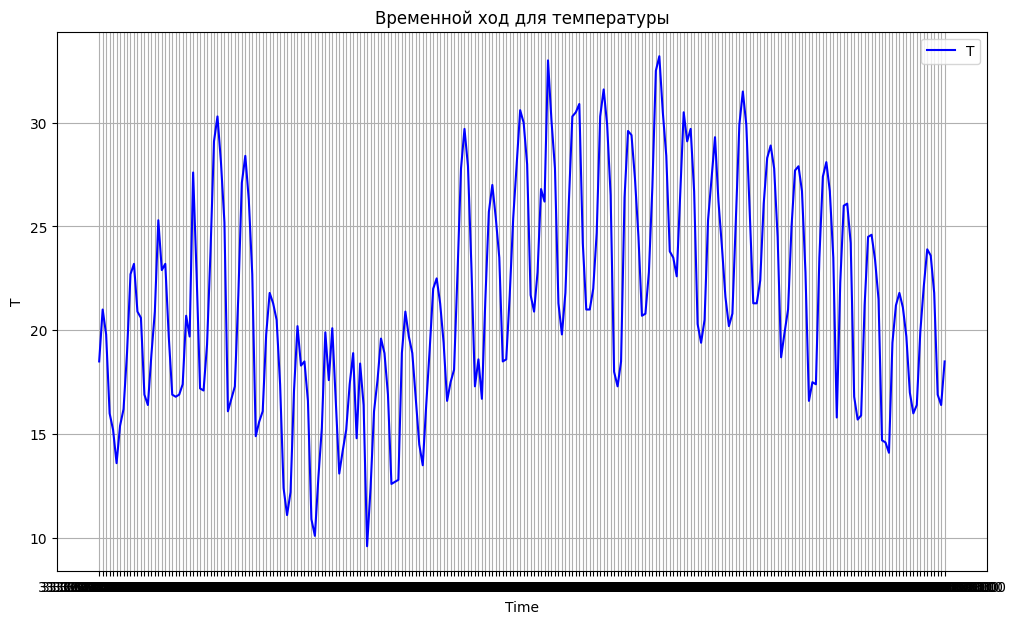

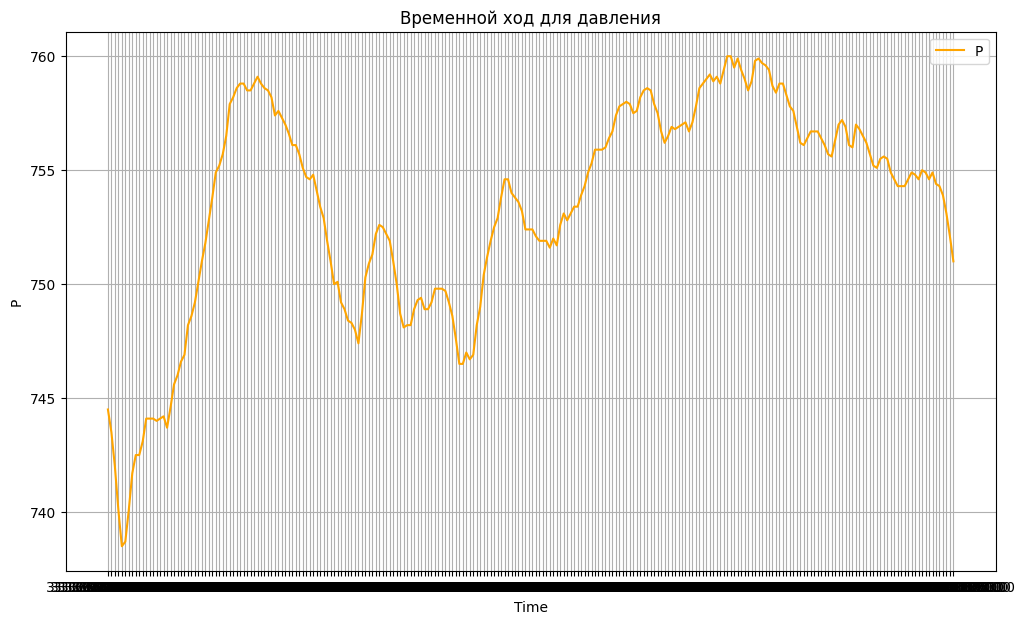

In [10]:
file = 'July.xlsx'
data = pd.read_excel(file)

plt.figure(figsize=(12,7))
plt.plot(data['Время'], data['Температура'], label = 'T', color = 'blue')

plt.title ('Временной ход для температуры')
plt.xlabel('Time')
plt.ylabel('T')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,7))
plt.plot(data['Время'], data['Давление'], label = 'P', color = 'orange')

plt.title ('Временной ход для давления')
plt.xlabel('Time')
plt.ylabel('P')
plt.legend()
plt.grid(True)
plt.show()


In [14]:
!pip install cartopy

In [20]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

('lat', 'lon')
(720, 1440)


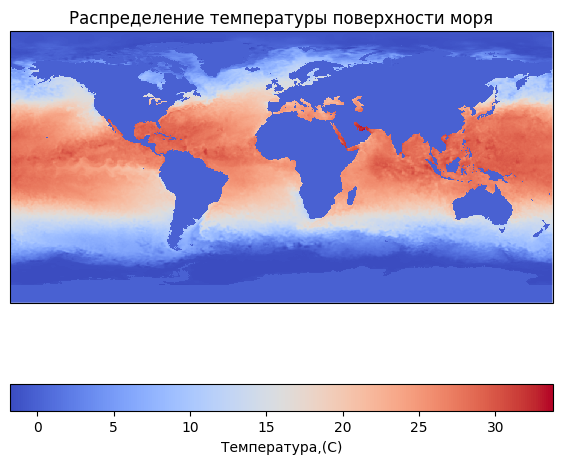

In [63]:
file = 'sst.nc'
data = xr.open_dataset(file)

sst = data['sst']
sst = sst.fillna(0)
sst = sst.mean(dim='time')
sst = sst.mean(dim='zlev')

plt.figure(figsize=(7,7))
ax = plt.axes(projection = ccrs.PlateCarree())
ax.set_global()

print(sst.dims)
print(sst.shape)

lon_coord = sst['lon'].values
lat_coord = sst['lat'].values

lon_edge = np.linspace(lon_coord[0], lon_coord[-1], len(lon_coord) + 1)
lat_edge = np.linspace(lat_coord[0], lat_coord[-1], len(lat_coord) + 1)

temp = plt.pcolormesh(lon_edge, lat_edge, sst, transform = ccrs.PlateCarree(), cmap = 'coolwarm', shading = 'flat')

plt.colorbar(temp, label = 'Температура,(C)', orientation = 'horizontal')
plt.title('Распределение температуры поверхности моря')

plt.show()

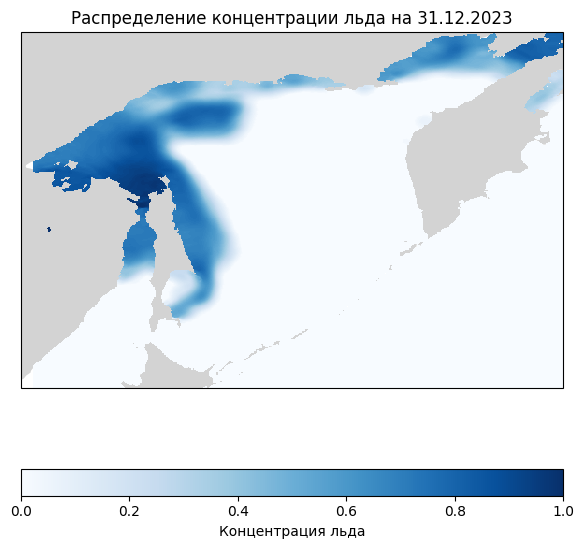

In [61]:
file = 'sea_ice.nc'
data = xr.open_dataset(file)

sea_ice_fraction = data['sea_ice_fraction']
#print(sea_ice_fraction)
sea_ice_3112 = sea_ice_fraction.sel(time = '2023-12-31')

lon = sea_ice_3112['longitude'].values
lat = sea_ice_3112['latitude'].values

plt.figure(figsize = (7,7))
ax = plt.axes(projection = ccrs.PlateCarree())
ax.set_extent([135, 164, 43, 62], crs = ccrs.PlateCarree())

fraction = ax.pcolormesh(lon, lat, sea_ice_3112.values, transform = ccrs.PlateCarree(), cmap = 'Blues', shading = 'auto')

ax.add_feature(cfeature.LAND, color = 'lightgray')
plt.colorbar(fraction, label = 'Концентрация льда', orientation = 'horizontal')
plt.title('Распределение концентрации льда на 31.12.2023')

plt.show()

In [59]:
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 'turbo_r', 'Blues_r', 'BrBG_r', '